<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TimeA006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

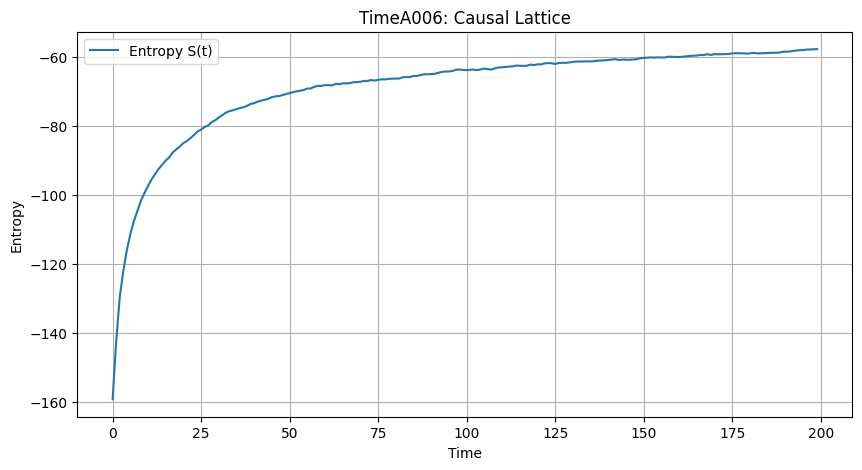

TimeA006 Metrics:
Entropy Slope: 0.19202
Memory Retention: 0.99789
Irreversibility Index: 107.08586
Geometric Deformation (std of drift): 0.00000


In [1]:
# 🧠 TimeA006: The Causal Lattice
# Testing whether entropic drift seeds geometric structure in HES lattice
# Author: Chris & Copilot | Arc V: Entropic Ascent | ACT030
# Reproducibility Tag: TimeA006_v1

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 100  # lattice size
T = 200  # timesteps
curvature_strength = 0.5
xi_locking = True
bias_strength = 0.05
seed = 42
np.random.seed(seed)

# --- Initialization ---
def initialize_lattice(N, curvature_strength):
    base = np.random.rand(N, N)
    curvature = curvature_strength * (np.sin(np.linspace(0, np.pi, N))[:, None])
    return base + curvature

# --- Entropy Calculation ---
def compute_entropy(lattice):
    hist, _ = np.histogram(lattice, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

# --- Drift Calculation ---
def compute_drift(lattice, prev_lattice):
    return lattice - prev_lattice

# --- Evolution Function ---
def evolve_lattice(lattice, xi_locking, bias_strength, cumulative_drift):
    entropy_map = np.gradient(lattice)[0]
    lattice += 0.01 * np.random.randn(*lattice.shape) + bias_strength * entropy_map
    cumulative_drift += compute_drift(lattice, lattice.copy())
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice, cumulative_drift

# --- Simulation Loop ---
def run_simulation(N, T, curvature_strength, xi_locking, bias_strength):
    lattice = initialize_lattice(N, curvature_strength)
    cumulative_drift = np.zeros_like(lattice)
    entropy_series = []
    for t in range(T):
        lattice, cumulative_drift = evolve_lattice(lattice, xi_locking, bias_strength, cumulative_drift)
        S = compute_entropy(lattice)
        entropy_series.append(S)
    return np.array(entropy_series), cumulative_drift

# --- Run Biased Evolution ---
entropy_series, cumulative_drift = run_simulation(N, T, curvature_strength, xi_locking, bias_strength)

# --- Metrics ---
def compute_metrics(entropy_series, cumulative_drift):
    slope = np.polyfit(np.arange(len(entropy_series)), entropy_series, 1)[0]
    memory = np.corrcoef(entropy_series[:-1], entropy_series[1:])[0,1]
    irreversibility_index = np.sum(np.abs(np.diff(entropy_series)))
    deformation = np.std(cumulative_drift)
    return slope, memory, irreversibility_index, deformation

slope, memory, irreversibility_index, deformation = compute_metrics(entropy_series, cumulative_drift)

# --- Plotting ---
plt.figure(figsize=(10,5))
plt.plot(entropy_series, label='Entropy S(t)')
plt.xlabel('Time')
plt.ylabel('Entropy')
plt.title('TimeA006: Causal Lattice')
plt.legend()
plt.grid(True)
plt.show()

# --- Output ---
print("TimeA006 Metrics:")
print(f"Entropy Slope: {slope:.5f}")
print(f"Memory Retention: {memory:.5f}")
print(f"Irreversibility Index: {irreversibility_index:.5f}")
print(f"Geometric Deformation (std of drift): {deformation:.5f}")
